In [1]:
LOG_DIR = '../../experiments/current/'


In [2]:
# Parameters
LOG_DIR = "/Users/yvesb/Documents/Projects/llm-agents-gama/experiments/archive/2026-08-24_17_34/"


In [3]:
import os
import matplotlib.pyplot as plt
import yaml
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

import sys
!{sys.executable} -m pip install --upgrade kaleido



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /Users/yvesb/Documents/Projects/llm-agents-gama/llm-agents/.venv/bin/python -m pip install --upgrade pip


In [4]:
mode_colors = {
    'marche': 'cyan',
    'voiture': 'red',
    'velo': 'purple',
    'transports_collectifs': 'green'
}

mode_order = ['marche', 'voiture', 'velo', 'transports_collectifs']

def _img_path(title, ext="png"):
    name = "".join(c if c.isalnum() or c in "-_" else "_" for c in title)
    img_dir = os.path.join(LOG_DIR, "images/stats")
    os.makedirs(img_dir, exist_ok=True)
    return os.path.join(img_dir, f"{name}.{ext}")

def pie_graph(subset,reference_cerema, title):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    colors = [mode_colors.get(label, 'gray') for label in mode_order]

    # For ax1
    counts1 = subset["Plus rapide"].value_counts().reindex(mode_order).fillna(0)
    if (counts1.isna().any()):
        print("Warning: Some modes in 'Plus rapide' are not in the predefined mode order."+str(counts1))
    ax1.pie(counts1, labels=mode_order, colors=colors, autopct='%1.1f%%')
    ax1.set_title("Plus rapide")

    # For ax2
    counts2 = subset["Mode de transport Choisi"].value_counts().reindex(mode_order).fillna(0)
    ax2.pie(counts2, labels=mode_order, colors=colors, autopct='%1.1f%%')
    ax2.set_title("Agent LLM")

    # For ax3
    if "autres_modes" in reference_cerema:
        reference_cerema.pop("autres_modes")

    reference_series = pd.Series(reference_cerema, name="Percentage")
    reference_series = reference_series.reindex(mode_order).fillna(0)
    
    ax3.pie(reference_series, labels=mode_order, colors=colors, autopct='%1.1f%%')
    ax3.set_title("Enquête mobilité certifiée Cerema")

    fig.suptitle(title)

    plt.tight_layout()
    fig.savefig(_img_path(title), bbox_inches='tight', dpi=150)
    plt.show()


def bar_graph(subset, reference_cerema, title, x_name):

    if x_name not in subset.columns:
        print(f"Error: The specified x_name '{x_name}' is not a column in the dataset.")
        print(f"Available columns: {subset.columns.tolist()}")
        return

    reference_order = list(reference_cerema.keys())
    if set(subset[x_name].unique()) != set(reference_order):
        print(f"Warning: The unique values in the dataset for '{x_name}' do not match the keys in the reference data.")
        print(f"Dataset values: {subset[x_name].unique().tolist()}")
        print(f"Reference keys: {reference_order}")
        
    # 1. Préparation des données
    df_fast = subset.groupby([x_name, "Plus rapide"]).size().reset_index(name='count')
    df_llm = subset.groupby([x_name, "Mode de transport Choisi"]).size().reset_index(name='count')
    
    df_cerema = pd.DataFrame.from_dict(reference_cerema, orient="index").reset_index()
    df_cerema.rename(columns={"index": x_name}, inplace=True)

    df_cerema = df_cerema.reset_index().melt(
        id_vars=x_name,
        var_name='Mode de transport Choisi', 
        value_name='count'
    )

    for df in [df_fast, df_llm, df_cerema]:
        df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
        df.sort_values(x_name, inplace=True)

    fig = make_subplots(rows=1, cols=3, subplot_titles=("Plus rapide", "Agent LLM", "Enquête Cerema"))

    # Fonction utilitaire pour ajouter les traces avec couleurs et labels
    def add_mode_traces(fig, df, mode_col, val_col, column, show_legend_start):
        for i, mode in enumerate(mode_order):
            data = df[df[mode_col] == mode]
            # On n'affiche la légende que pour le premier subplot pour éviter les doublons
            show_v_legend = True if (show_legend_start and i < len(mode_order)) else False
            
            fig.add_trace(
                go.Bar(
                    x=data[x_name],
                    y=data[val_col],
                    name=mode,
                    marker_color=mode_colors.get(mode, 'gray'),
                    legendgroup=mode,
                    showlegend=show_v_legend,
                    # Configuration du texte en %
                    texttemplate='%{text:.1f}%',
                    textposition='inside',
                    # Calcul manuel du texte (requis car barnorm est au niveau layout)
                    text=[(v / df[df[x_name] == x]["count" if "count" in df else "Value"].sum()) * 100 
                          for x, v in zip(data[x_name], data[val_col])]
                ),
                row=1, col=column
            )

    # Ajout des traces pour les 3 subplots
    add_mode_traces(fig, df_fast, "Plus rapide", "count", 1, True)
    add_mode_traces(fig, df_llm, "Mode de transport Choisi", "count", 2, False)
    add_mode_traces(fig, df_cerema, "Mode de transport Choisi", "count", 3, False)

    # Configuration globale
    fig.update_layout(
        title_text=title,
        barmode="relative",
        barnorm="percent",
        height=600,
        width=1300,
        bargap=0.5,
        legend_title="Modes",
        yaxis_title="Pourcentage (%)",
    )

    fig.update_xaxes(
        type='category', 
        categoryorder='array', 
        categoryarray=reference_order,
        showgrid=False
    )

    fig.write_image(_img_path(title), scale=2)
    fig.show()


In [5]:
with open("../data/population/cerema_values.yaml", "r") as f:
    cerema = yaml.safe_load(f)

# Exemple : Accéder aux parts modales de Toulouse
print(cerema["parts_modales_2023"]["global"])

def print_cerema_parts_modales(cerema,key0):
    total = 0
    for key, value in cerema[key0].items():
        if isinstance(cerema[key0][key], dict):
            print_cerema_parts_modales(cerema[key0],key)
        else:
            total = total + value
    if (total != 100) and (total > 0):
        print(f"Warning: Total for {key0} is {total}%, expected 100%.")

print_cerema_parts_modales(cerema,"parts_modales_2023")

{'voiture': 55, 'marche': 26, 'transports_collectifs': 12, 'velo': 4, 'autres_modes': 3}


In [6]:
#moves = pd.read_csv('../../experiments/current/moves.csv')
moves = pd.read_csv(LOG_DIR + 'moves.csv')

#moves = pd.read_csv('../../experiments/2026-05-07_12_23/moves.csv')
moves = moves[moves["Distance parcourue"]>0]

# Normalisation des noms de modes de transport
moves.replace({'Marche':"marche", 'Voiture Privée':"voiture", 'Vélo':"velo", 'Bus':"transports_collectifs", 'Transports_collectifs':"transports_collectifs"}, inplace=True)

# Normalisation des catégories d'occupation
moves.replace({'Travail à plein temps':"actif_temps_plein", "Scolaire (jusqu'au Bac)":"scolaire", "Chômeur/recherche d'emploi":"chomeur_recherche_emploi", 'Personne au foyer':"personne_au_foyer", 'Travail à temps partiel':"actif_temps_partiel", 'Étudiant':"etudiant"}, inplace=True)


# Dataset values: ['Achats', 'Travail', 'leisure', 'Etude', 'home']
# Reference keys: ['domicile_travail', 'domicile_etudes', 'domicile_achats', 'domicile_accompagnement']²
moves.replace({'Achats':"achats", 'Travail':"travail", 'leisure':"loisirs", 'Etude':"etudes"}, inplace=True)

# Dataset values: ['1ere couronne', '2eme couronne', 'Toulouse']
# Reference keys: ['Toulouse', '1ere_couronne', '2eme_couronne', '3eme_couronne']
moves.replace({'1ere couronne':"1ere_couronne", '2eme couronne':"2eme_couronne"}, inplace=True)

display(moves.describe())
moves.head()

,Trajet,P(Marche) %,P(Vélo) %,P(Voiture Privée) %,P(Transports_collectifs) %,P(Train) %,P(Deux-roues motorisé) %,P(Autres modes) %,Âge,Distance parcourue,Température,Météo Température (°C),Météo Précipitations (mm),Retard planification (s),Temps simulé,ID Personne
count,5122.000000,3369.000000,3369.000000,3369.000000,3369.000000,3369.0,3369.0,3369.0,5122.000000,5122.000000,5122.0,5122.000000,5122.0,5122.0,5.122000e+03,5.122000e+03
mean,2671.459391,13.839567,11.332651,50.228080,24.599763,0.0,0.0,0.0,40.469738,7.299168,0.0,9.774307,0.0,0.0,1.773696e+09,7.640077e+05
std,1537.162486,28.710553,24.400004,41.902798,35.827966,0.0,0.0,0.0,22.175323,7.468779,0.0,4.669952,0.0,0.0,4.561079e+04,4.090303e+05
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,5.000000,0.030000,0.0,3.000000,0.0,0.0,1.773637e+09,5.327000e+03
25%,1336.250000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,23.000000,1.950000,0.0,6.000000,0.0,0.0,1.773662e+09,4.052340e+05
50%,2680.500000,0.000000,0.000000,60.000000,5.000000,0.0,0.0,0.0,37.000000,4.720000,0.0,12.000000,0.0,0.0,1.773686e+09,7.951990e+05
75%,4001.750000,10.000000,10.000000,90.000000,30.000000,0.0,0.0,0.0,56.000000,10.370000,0.0,13.000000,0.0,0.0,1.773737e+09,1.099533e+06
max,5343.000000,100.000000,100.000000,100.000000,100.000000,0.0,0.0,0.0,96.000000,51.080000,0.0,17.000000,0.0,0.0,1.773964e+09,1.453593e+06


,Référence,Trajet,ID Trajet,Mode de transport Choisi,Plus rapide,Modes proposés au LLM,P(Marche) %,P(Vélo) %,P(Voiture Privée) %,P(Transports_collectifs) %,...,Météo Température (°C),Météo Condition,Météo Précipitations (mm),Raisonnement,Retard planification (s),Heure de calcul,Temps simulé,Heure de départ,ID Personne,ID Activité
1,2026-08-24_17_34,2,c376a438-50ff-47df-b7ee-994eb1ed5059,voiture,voiture,Voiture Privée | Vélo | Marche,10.0,30.0,60.0,0.0,...,3.0,Ciel dégagé/Ensoleillé,0.0,La voiture offre le meilleur confort pour les ...,0,2026-08-24T20:24:31+00:00,1773637201,2026-03-16 11:06:31,47675,511a53b8-688b-5a9f-9ea3-d5cfd1ec1e9e
2,2026-08-24_17_34,3,381c6229-1952-47bf-bf5f-d37b466f01b8,voiture,voiture,Voiture Privée | Vélo | Marche,0.0,5.0,95.0,0.0,...,3.0,Ciel dégagé/Ensoleillé,0.0,La distance de 21 km rend la voiture indispens...,0,2026-08-24T20:24:31+00:00,1773637201,2026-03-16 09:07:04,65912,8d508a52-b2d9-5bd7-8c40-35a942697506
3,2026-08-24_17_34,4,91686e7e-efba-4d48-8093-6aee2e0c7181,voiture,voiture,Voiture Privée | Vélo | Marche,10.0,20.0,70.0,0.0,...,3.0,Ciel dégagé/Ensoleillé,0.0,La voiture est privilégiée pour le confort the...,0,2026-08-24T20:24:31+00:00,1773637201,2026-03-16 07:53:13,76326,0fdba1ed-af3a-51db-abf5-dc695a71071d
4,2026-08-24_17_34,5,ecf072c9-83ab-4ddd-9ba6-1cf4e2e419db,marche,voiture,Voiture Privée | Marche,80.0,0.0,20.0,0.0,...,3.0,Ciel dégagé/Ensoleillé,0.0,La marche est largement préférée car la distan...,0,2026-08-24T20:24:31+00:00,1773637201,2026-03-16 13:53:56,47674,8cfecb1f-c79a-5ac1-b3a8-2d349f744281
5,2026-08-24_17_34,6,2eff44dc-c86b-46a7-a401-9f99019c368a,voiture,voiture,Voiture Privée | Marche,0.0,0.0,100.0,0.0,...,3.0,Ciel dégagé/Ensoleillé,0.0,"La distance de 5,6 km et l'absence de vélo ren...",0,2026-08-24T20:24:31+00:00,1773637201,2026-03-16 13:25:25,83410,d14c37d4-ff86-514c-95af-126a4cd2cbaa


In [7]:
bins = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 131]
labels = ['5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-130']

moves['Age_cat'] = pd.cut(moves['Âge'], bins=bins, labels=labels, right=False)

In [8]:
print(mode_order)


['marche', 'voiture', 'velo', 'transports_collectifs']


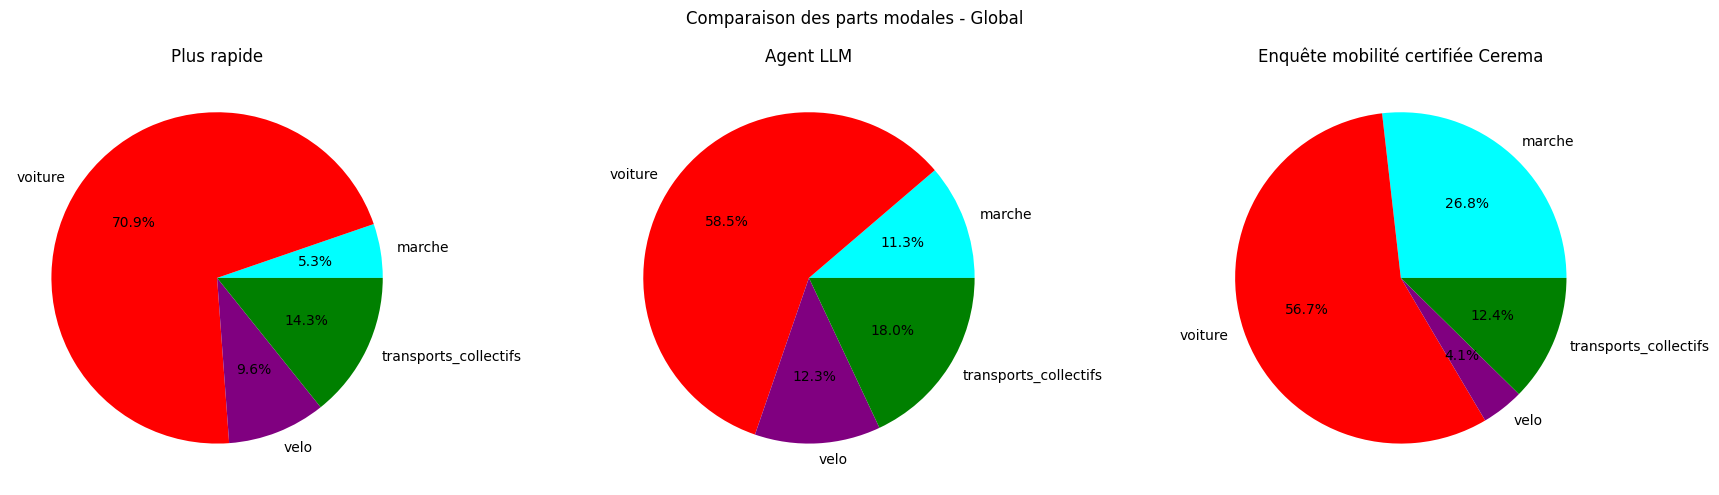

In [9]:
pie_graph(moves, cerema["parts_modales_2023"]["global"], "Comparaison des parts modales - Global")

In [10]:
bar_graph(moves, cerema["parts_modales_2023"]["genre"], "Comparaison des parts modales par genre", x_name="Genre")


In [11]:
bar_graph(moves, cerema["parts_modales_2023"]["Age"], "Comparaison des parts modales par âge", x_name="Age_cat")


In [12]:
bar_graph(moves, cerema["parts_modales_2023"]["lieu_residence"], "Comparaison des parts modales par lieux de résidence", x_name="Lieu de résidence")

Dataset values: ['3eme couronne', '2eme_couronne', '1ere_couronne', 'Toulouse']
Reference keys: ['Toulouse', '1ere_couronne', '2eme_couronne', '3eme_couronne']


/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_49730/2783383109.py:77: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_49730/2783383109.py:77: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_49730/2783383109.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  text=[(v / df[df[x_name] == x]["count" if "count" in df else "Value"].sum()) * 100


In [13]:
bar_graph(moves, cerema["parts_modales_2023"]["occupation"], "Comparaison des parts modales selon l'occupation principale", x_name="Occupation principale")

In [14]:
#bar_graph(moves, cerema["parts_modales_2023"]["type_logement"], "Comparaison des parts modales des Hommes", x_name="Type de logement")

In [15]:
bar_graph(moves, cerema["parts_modales_2023"]["motif_deplacement"], "Comparaison des parts modales selon le motif de déplacement", x_name="Motifs de déplacement")

Dataset values: ['other', 'loisirs', 'home', 'travail', 'etudes', 'achats']
Reference keys: ['travail', 'etudes', 'achats', 'accompagnement']


/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_49730/2783383109.py:77: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_49730/2783383109.py:77: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_49730/2783383109.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  text=[(v / df[df[x_name] == x]["count" if "count" in df else "Value"].sum()) * 100


In [16]:
moves["rayon"] = pd.cut(moves["Distance parcourue"], bins=[0, 1, 2, 5, 10, 20, 50, float('inf')], labels=["0-1km", "1-2km", "2-5km", "5-10km", "10-20km", "20-50km", "50km+"])
bar_graph(moves, cerema["parts_modales_2023"]["distance"], "Comparaison des parts modales selon le rayon de déplacement", x_name="rayon")

Dataset values: ['1-2km', '20-50km', '0-1km', '2-5km', '10-20km', '5-10km', '50km+']
Reference keys: ['0-1km', '1-2km', '2-5km', '5-10km', '10-20km', '20-50km', 'plus_50km']


/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_49730/2783383109.py:77: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_49730/2783383109.py:77: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[x_name] = pd.Categorical(df[x_name], categories=reference_order, ordered=True)
/var/folders/sd/yfpxc_y13hqfry2rspfkspq80000gr/T/ipykernel_49730/2783383109.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  text=[(v / df[df[x_name] == x]["count" if "count" in df else "Value"].sum()) * 100


## Répartition attendue vs tirée

Depuis le choix modal probabiliste, `moves.csv` porte une colonne par mode
(`P(Marche) %`, …) : la répartition que le LLM a annoncée **avant** le tirage.

Le tirage la reproduit en espérance — un écart franc et durable ne vient donc pas
du modèle, mais du tirage, du cache (points hérités resservis sans tirage) ou de la
normalisation. Les décisions sans répartition (mono-choix, erreur LLM) sont exclues
des deux côtés : les inclure gonflerait mécaniquement l'écart.


In [17]:
import os, sys
sys.path.append(os.getcwd())  # scripts/analysis/
from mode_probabilities import load_moves, expected_vs_drawn, hesitation, has_distribution

moves = load_moves(os.path.join(LOG_DIR, 'moves.csv'))
n_proba = int(has_distribution(moves).sum())
print(f"{n_proba}/{len(moves)} décisions issues d'un tirage probabiliste")

# Part attendue (moyenne des probabilités annoncées) vs part tirée (modes retenus).
display(expected_vs_drawn(moves).round(1))

# Hésitation : 1 − p_max. Information inaccessible avant la bascule — elle sépare
# « la voiture est une évidence » de « ç'aurait aussi bien pu être le bus ».
h = hesitation(moves).dropna()
if not h.empty:
    print(f"hésitation moyenne : {h.mean():.2f} · décisions très hésitantes (>0.5) : "
          f"{100 * (h > 0.5).mean():.0f} %")


3369/5343 décisions issues d'un tirage probabiliste


,attendu %,tiré %,écart (pts)
Marche,13.8,14.4,0.6
Vélo,11.3,10.9,-0.4
Transports_collectifs,24.6,24.4,-0.2
Voiture Privée,50.2,50.3,0.1
Autres modes,0.0,0.0,0.0
Deux-roues motorisé,0.0,0.0,0.0
Train,0.0,0.0,0.0


hésitation moyenne : 0.15 · décisions très hésitantes (>0.5) : 2 %
